# PharmaTrade-MM Phase 3: PPO Price-Only Baseline (Ablation 1)

This notebook implements full Phase 3:
1. Train PPO on **price-only** state features
2. Backtest on test period
3. Compare against baselines (Buy & Hold, Equal-Weight Monthly, 20-day Momentum, XPH)
4. Compute metrics and save outputs


In [19]:
# Optional installs (uncomment if needed)
%pip install gymnasium stable-baselines3 matplotlib



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    HAS_MATPLOTLIB = False
    print("matplotlib missing; plotting cells will be skipped.")

from phase2_trading_env import make_env_from_processed, DEFAULT_TICKERS

try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv
    SB3_AVAILABLE = True
except ModuleNotFoundError:
    SB3_AVAILABLE = False
    print("stable-baselines3 missing. Install it to train PPO.")


In [21]:
# Paths and run config
TRAIN_PATH = "processed/train_dataset.csv"
TEST_PATH = "processed/test_dataset.csv"
FEATURE_CONFIG_PATH = "processed/feature_config.json"
XPH_PATH = "processed/xph_processed.csv"

RESULTS_DIR = Path("results/phase3_price_only")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = RESULTS_DIR / "ppo_price_only.zip"
TOTAL_TIMESTEPS = 50_000
SEED = 42

# Optional: load tuned hyperparameters from phase3_hyperparam_tuning.ipynb output
BEST_PARAM_JSON = Path("results/phase3_tuning/best_params_price_only.json")

with open(FEATURE_CONFIG_PATH, "r") as f:
    feature_cfg = json.load(f)

price_features = feature_cfg["price_features"]
print("Using price-only features:", price_features)
print("Num price features:", len(price_features))

default_ppo_params = {
    "learning_rate": 3e-4,
    "n_steps": 2048,
    "batch_size": 256,
    "n_epochs": 10,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "ent_coef": 0.0,
    "vf_coef": 0.5,
    "clip_range": 0.2,
}

ppo_params = default_ppo_params.copy()
if BEST_PARAM_JSON.exists():
    with open(BEST_PARAM_JSON, "r") as f:
        tuned_payload = json.load(f)
    tuned = tuned_payload.get("best_params", {})
    ppo_params.update(tuned)
    print("Loaded tuned PPO params from", BEST_PARAM_JSON)
else:
    print("Tuned param file not found. Using default PPO params.")

print("PPO params:", ppo_params)


Using price-only features: ['open', 'high', 'low', 'close', 'volume', 'rsi', 'macd', 'macd_signal', 'macd_diff', 'bb_upper', 'bb_middle', 'bb_lower', 'bb_pct', 'bb_width', 'log_return', 'volume_sma20', 'volume_ratio']
Num price features: 17
Loaded tuned PPO params from results/phase3_tuning/best_params_price_only.json
PPO params: {'learning_rate': 0.00014312907952658717, 'n_steps': 512.0, 'batch_size': 512.0, 'n_epochs': 10.0, 'gamma': 0.995, 'gae_lambda': 0.9, 'ent_coef': 0.001, 'vf_coef': 0.75, 'clip_range': 0.3}


In [22]:
# Build train/test envs for price-only ablation
# Note: event scaling disabled in this ablation.

def build_price_only_env(dataset_path: str):
    return make_env_from_processed(
        dataset_path=dataset_path,
        feature_config_path=FEATURE_CONFIG_PATH,
        tickers=DEFAULT_TICKERS,
        feature_columns_override=price_features,
        initial_cash=1_000_000.0,
        transaction_cost=0.001,
        trade_fraction=0.10,
        use_event_scaling=False,
    )

train_env = build_price_only_env(TRAIN_PATH)
test_env = build_price_only_env(TEST_PATH)

obs, info = train_env.reset(seed=SEED)
print("Train env observation shape:", obs.shape)
print("Train env action space:", train_env.action_space)
print("Train env features:", train_env.num_features)


Train env observation shape: (145,)
Train env action space: MultiDiscrete([3 3 3 3 3 3 3 3])
Train env features: 17


In [23]:
# Train PPO
if not SB3_AVAILABLE:
    raise ModuleNotFoundError("stable-baselines3 not installed. Run install cell and retry.")

vec_train_env = DummyVecEnv([lambda: build_price_only_env(TRAIN_PATH)])

# Enforce int types for params that must be integers (JSON may deserialize them as float)
ppo_params["n_steps"] = int(ppo_params["n_steps"])
ppo_params["batch_size"] = int(ppo_params["batch_size"])
ppo_params["n_epochs"] = int(ppo_params["n_epochs"])

model = PPO(
    "MlpPolicy",
    vec_train_env,
    verbose=1,
    seed=SEED,
    **ppo_params,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS)
model.save(str(MODEL_PATH))
print("Saved model:", MODEL_PATH)


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 2873 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 512  |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 2735         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 0.0046258024 |
|    clip_fraction        | 0.00117      |
|    clip_range           | 0.3          |
|    entropy_loss         | -8.79        |
|    explained_variance   | -0.277       |
|    learning_rate        | 0.000143     |
|    loss                 | 0.306        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.0115      |
|    value_loss           | 0.458        |
------------------------------------------

In [24]:
# PPO backtest on test env (deterministic)

def run_ppo_backtest(env, trained_model):
    obs, info = env.reset(seed=SEED)
    done = False

    rows = []
    action_rows = []

    while not done:
        action, _ = trained_model.predict(obs, deterministic=True)
        obs, reward, done, _, step_info = env.step(action)

        rows.append({
            "date": step_info["date"],
            "portfolio_value": step_info["portfolio_value"],
            "daily_return": step_info["daily_return"],
            "reward": reward,
            "drawdown": step_info["drawdown"],
            "sharpe": step_info["sharpe"],
            "cvar_penalty": step_info["cvar_penalty"],
        })

        a = np.asarray(action).reshape(-1)
        action_rows.append({"date": step_info["date"], **{f"act_{t}": int(a[i]) for i, t in enumerate(DEFAULT_TICKERS)}})

    perf = pd.DataFrame(rows)
    perf["date"] = pd.to_datetime(perf["date"])
    perf = perf.sort_values("date").reset_index(drop=True)

    actions = pd.DataFrame(action_rows)
    actions["date"] = pd.to_datetime(actions["date"])
    actions = actions.sort_values("date").reset_index(drop=True)

    return perf, actions

ppo_perf, ppo_actions = run_ppo_backtest(test_env, model)
ppo_perf.head()


,date,portfolio_value,daily_return,reward,drawdown,sharpe,cvar_penalty
0,2022-01-04,9.997291e+05,-0.000271,-0.000298,0.000271,0.000000,0.0
1,2022-01-05,9.990150e+05,-0.000198,-3.585692,0.000985,-71.707923,0.0
2,2022-01-06,1.003705e+06,-0.000182,-0.034346,0.000000,-72.391213,0.0
3,2022-01-07,1.000488e+06,-0.000120,1.161484,0.003205,-49.152739,0.0
4,2022-01-10,1.008580e+06,-0.000078,0.647367,0.000000,-36.203839,0.0


In [25]:
# Baselines on test set

test_df = pd.read_csv(TEST_PATH, parse_dates=["date"])
price_pivot = test_df.pivot(index="date", columns="ticker", values="close").sort_index()
price_pivot = price_pivot[DEFAULT_TICKERS]
rets = price_pivot.pct_change().fillna(0.0)


def normalize_to_1m(series):
    return series / series.iloc[0] * 1_000_000.0


def max_drawdown(equity):
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())


def annualized_sharpe(daily_ret):
    s = daily_ret.std(ddof=1)
    if s <= 1e-12:
        return 0.0
    return float((daily_ret.mean() / s) * np.sqrt(252))


def annualized_sortino(daily_ret):
    downside = daily_ret[daily_ret < 0]
    ds = downside.std(ddof=1) if len(downside) > 1 else 0.0
    if ds <= 1e-12:
        return 0.0
    return float((daily_ret.mean() / ds) * np.sqrt(252))


def win_rate(daily_ret):
    return float((daily_ret > 0).mean())


def simulate_buy_hold_equal(prices):
    shares = (1_000_000.0 / len(prices.columns)) / prices.iloc[0]
    equity = (prices * shares).sum(axis=1)
    daily = equity.pct_change().fillna(0.0)
    return equity, daily


def simulate_equal_weight_monthly(prices, tc=0.001):
    dates = prices.index
    n = prices.shape[1]
    target_w = np.repeat(1.0 / n, n)
    weights = target_w.copy()
    equity = [1_000_000.0]
    prev_month = dates[0].month

    for i in range(1, len(dates)):
        cur_month = dates[i].month
        r = prices.iloc[i].values / prices.iloc[i - 1].values - 1.0
        gross_ret = float(np.dot(weights, r))
        value = equity[-1] * (1.0 + gross_ret)

        # Drifted weights after return
        numer = weights * (1.0 + r)
        denom = numer.sum()
        weights = numer / denom if denom > 0 else target_w.copy()

        # Rebalance at month change
        if cur_month != prev_month:
            turnover = np.abs(target_w - weights).sum()
            value = value * (1.0 - tc * turnover)
            weights = target_w.copy()
        prev_month = cur_month
        equity.append(value)

    equity = pd.Series(equity, index=dates)
    daily = equity.pct_change().fillna(0.0)
    return equity, daily


def simulate_momentum_20d(prices, top_k=3, tc=0.001):
    dates = prices.index
    n = prices.shape[1]
    momentum = prices.pct_change(20).shift(1)

    weights = np.zeros(n)
    equity = [1_000_000.0]

    for i in range(1, len(dates)):
        m = momentum.iloc[i].values
        valid = np.where(np.isfinite(m) & (m > 0))[0]
        target = np.zeros(n)
        if len(valid) > 0:
            order = valid[np.argsort(m[valid])[::-1]]
            pick = order[:top_k]
            target[pick] = 1.0 / len(pick)

        turnover = np.abs(target - weights).sum()
        value = equity[-1] * (1.0 - tc * turnover)

        r = prices.iloc[i].values / prices.iloc[i - 1].values - 1.0
        gross_ret = float(np.dot(target, r))
        value = value * (1.0 + gross_ret)

        weights = target
        equity.append(value)

    equity = pd.Series(equity, index=dates)
    daily = equity.pct_change().fillna(0.0)
    return equity, daily

bh_equity, bh_daily = simulate_buy_hold_equal(price_pivot)
ew_equity, ew_daily = simulate_equal_weight_monthly(price_pivot)
mo_equity, mo_daily = simulate_momentum_20d(price_pivot)

xph = pd.read_csv(XPH_PATH, parse_dates=["date"]).sort_values("date")
xph = xph[(xph["date"] >= price_pivot.index.min()) & (xph["date"] <= price_pivot.index.max())].copy()
xph_equity = normalize_to_1m(xph.set_index("date")["close"])
xph_daily = xph_equity.pct_change().fillna(0.0)

ppo_equity = ppo_perf.set_index("date")["portfolio_value"]
ppo_daily = ppo_equity.pct_change().fillna(0.0)

print("Baselines generated.")


Baselines generated.


In [26]:
# Metrics + alpha vs XPH

def compute_metrics(name, equity, daily_ret, xph_daily_ret):
    common_idx = daily_ret.index.intersection(xph_daily_ret.index)
    aligned_ret = daily_ret.loc[common_idx]
    aligned_xph = xph_daily_ret.loc[common_idx]
    excess = aligned_ret - aligned_xph

    return {
        "strategy": name,
        "cumulative_return_pct": float((equity.iloc[-1] / equity.iloc[0] - 1.0) * 100.0),
        "ann_sharpe": annualized_sharpe(aligned_ret),
        "ann_sortino": annualized_sortino(aligned_ret),
        "max_drawdown_pct": float(max_drawdown(equity) * 100.0),
        "win_rate": win_rate(aligned_ret),
        "alpha_vs_xph_ann_pct": float(excess.mean() * 252 * 100.0),
    }

metric_rows = [
    compute_metrics("PPO_PriceOnly", ppo_equity, ppo_daily, xph_daily),
    compute_metrics("BuyHold_Equal", bh_equity, bh_daily, xph_daily),
    compute_metrics("EqualWeight_Monthly", ew_equity, ew_daily, xph_daily),
    compute_metrics("Momentum_20D", mo_equity, mo_daily, xph_daily),
    compute_metrics("XPH", xph_equity, xph_daily, xph_daily),
]
metrics_df = pd.DataFrame(metric_rows).sort_values("ann_sharpe", ascending=False).reset_index(drop=True)
metrics_df


,strategy,cumulative_return_pct,ann_sharpe,ann_sortino,max_drawdown_pct,win_rate,alpha_vs_xph_ann_pct
0,PPO_PriceOnly,12.106765,0.445379,0.718082,-15.215891,0.493014,9.152787
1,BuyHold_Equal,9.625921,0.377820,0.613220,-17.925456,0.508982,7.737318
2,EqualWeight_Monthly,8.460957,0.339634,0.554942,-18.982354,0.500998,7.237284
3,XPH,-8.074730,-0.090723,-0.145941,-22.619079,0.491018,0.000000
4,Momentum_20D,-8.401114,-0.171261,-0.254539,-24.221550,0.465070,-0.998788


## Results Interpretation

The Phase 3 price-only PPO baseline delivers the strongest overall test-period performance among all compared strategies. The PPO agent achieves the highest cumulative return (`12.11%`), highest risk-adjusted performance (Sharpe `0.445`, Sortino `0.718`), and the shallowest maximum drawdown (`-15.22%`). It also generates meaningful positive alpha versus the sector benchmark XPH (`+9.15%` annualized), indicating the policy adds value beyond passive exposure. In contrast, classical baselines (buy-and-hold and equal-weight monthly) remain profitable but materially weaker, while momentum and XPH are negative in this sample period.

In [27]:
# Save artifacts
metrics_path = RESULTS_DIR / "phase3_price_only_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

curve_df = pd.DataFrame({
    "date": ppo_equity.index,
    "ppo_price_only": ppo_equity.values,
    "buy_hold_equal": bh_equity.reindex(ppo_equity.index).values,
    "equal_weight_monthly": ew_equity.reindex(ppo_equity.index).values,
    "momentum_20d": mo_equity.reindex(ppo_equity.index).values,
    "xph": xph_equity.reindex(ppo_equity.index).values,
})
curve_path = RESULTS_DIR / "phase3_price_only_equity_curve.csv"
curve_df.to_csv(curve_path, index=False)

actions_path = RESULTS_DIR / "phase3_price_only_actions.csv"
ppo_actions.to_csv(actions_path, index=False)

print("Saved:")
print(" -", metrics_path)
print(" -", curve_path)
print(" -", actions_path)
print(" -", MODEL_PATH)


Saved:
 - results/phase3_price_only/phase3_price_only_metrics.csv
 - results/phase3_price_only/phase3_price_only_equity_curve.csv
 - results/phase3_price_only/phase3_price_only_actions.csv
 - results/phase3_price_only/ppo_price_only.zip


In [28]:
# Sanity checks
assert not curve_df.isnull().any().any(), "NaN found in equity curve output"
assert (curve_df[[c for c in curve_df.columns if c != "date"]] > 0).all().all(), "Non-positive portfolio value found"
assert len(ppo_actions) == len(ppo_perf), "Action log length mismatch"

action_cols = [c for c in ppo_actions.columns if c.startswith("act_")]
action_counts = pd.concat([ppo_actions[c].value_counts() for c in action_cols], axis=1).fillna(0)
print("Sanity checks passed.")
print("Action distribution by ticker (0=sell,1=hold,2=buy):")
action_counts


Sanity checks passed.
Action distribution by ticker (0=sell,1=hold,2=buy):


,count,count,count,count,count,count,count,count
2,485.0,501.0,500.0,0.0,0.0,0.0,496.0,0.0
0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,501.0,501.0,501.0,5.0,501.0


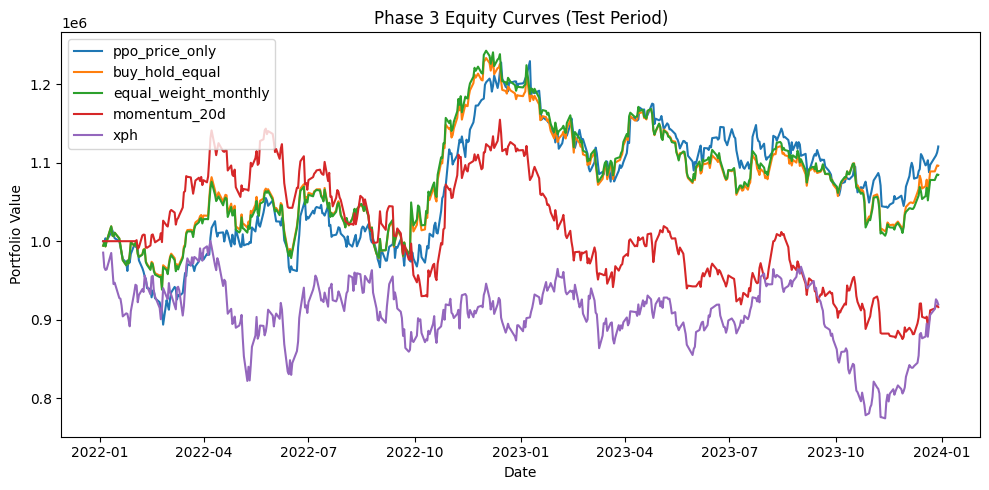

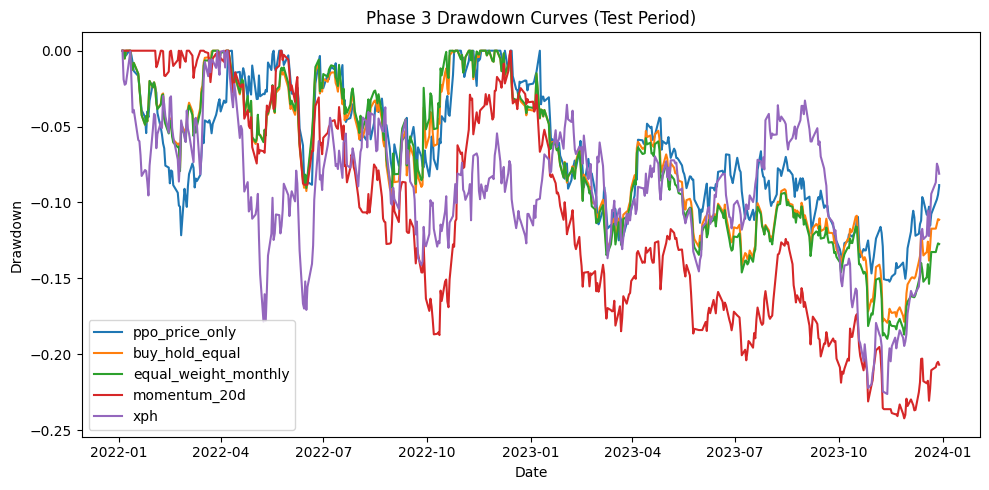

In [29]:
# Plots
if HAS_MATPLOTLIB:
    plt.figure(figsize=(10, 5))
    for c in ["ppo_price_only", "buy_hold_equal", "equal_weight_monthly", "momentum_20d", "xph"]:
        plt.plot(curve_df["date"], curve_df[c], label=c)
    plt.title("Phase 3 Equity Curves (Test Period)")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

    dd_df = curve_df.copy()
    for c in ["ppo_price_only", "buy_hold_equal", "equal_weight_monthly", "momentum_20d", "xph"]:
        peak = dd_df[c].cummax()
        dd_df[c] = dd_df[c] / peak - 1.0

    plt.figure(figsize=(10, 5))
    for c in ["ppo_price_only", "buy_hold_equal", "equal_weight_monthly", "momentum_20d", "xph"]:
        plt.plot(dd_df["date"], dd_df[c], label=c)
    plt.title("Phase 3 Drawdown Curves (Test Period)")
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Matplotlib not installed; plots skipped.")


## Phase 3 Completion Checklist

- PPO price-only model trained and saved
- Test backtest executed
- Baselines computed (Buy-Hold, Equal-Weight Monthly, 20D Momentum, XPH)
- Metrics table generated (Sharpe, Sortino, MaxDD, CumReturn, Alpha, WinRate)
- Artifacts exported to `results/phase3_price_only/`
